In [153]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal
from langchain_openai import ChatOpenAI
from pydantic import Field, BaseModel

from dotenv import load_dotenv
load_dotenv()  # take environment variables from .env file

True

In [154]:
model = ChatOpenAI(model_name='gpt-4o-mini')

class SentimentSchema(BaseModel):
    sentiment: Literal['positive', 'negative', 'neutral'] = Field(..., description="The sentiment of the text")

model_with_structured_output = model.with_structured_output(SentimentSchema)

# review = "Phone quality is not good. very bad experience. I am disappointed."

# result = model_with_structured_output.invoke(review)

# result

class DiagnosisSchema(BaseModel):
    tone : Literal['sad', 'calm', 'angry','disappointed'] = Field(..., description="The tone of the text")
    urgency : Literal['low', 'medium', 'high'] = Field(..., description="The urgency level of the text")    
    issue_type : Literal['product', 'service', 'delivery','other'] = Field(..., description="The issue type of the text")   

diagnosis_model = model.with_structured_output(DiagnosisSchema)

In [155]:
class SentimentState(TypedDict):
    text: str
    sentiment: Literal['positive', 'negative']
    diagnosis : dict
    response : str

In [156]:
# ...existing code...
def find_sentiment(state: SentimentState) -> Literal['positive', 'negative']:
    # accept dict or object but prefer dict access (langgraph passes a dict)
    text = state['text'] if isinstance(state, dict) else getattr(state, 'text', '')
    prompt = f"find out the sentiment of the following text: {text}. Is it positive or negative?"
    response = model_with_structured_output.invoke(prompt)

    # support both structured object and dict responses
    if hasattr(response, 'sentiment'):
        sentiment = response.sentiment
    elif isinstance(response, dict):
        sentiment = response.get('sentiment')
    else:
        raise RuntimeError("Unexpected response shape from model_with_structured_output")

    if sentiment not in ('positive', 'negative'):
        raise ValueError(f"Unexpected sentiment value: {sentiment}")

    return {'sentiment': sentiment}
# ...existing code...

In [157]:
def check_sentiment(state: SentimentState) -> Literal['positive', 'run_diagnosis']:
    sentiment = state['sentiment']
    if sentiment == 'positive':
        return 'positive'
    else:
        return 'run_diagnosis'

In [158]:
def positive(state: SentimentState):
    prompt = f"Send out positive response for the review: {state['text']}"

    response = model.invoke(prompt).content

    return {'response': response}

In [159]:
def run_diagnosis(state: SentimentState):
    text = state['text'] if isinstance(state, dict) else getattr(state, 'text', '')
    prompt = f"Analyze the following text and provide diagnosis in terms of tone, urgency and issue type: {text}"
    response = diagnosis_model.invoke(prompt)
    # support both pydantic model or dict
    if hasattr(response, 'model_dump'):
        diagnosis = response.model_dump()
    elif isinstance(response, dict):
        diagnosis = response
    else:
        raise RuntimeError("Unexpected diagnosis response")
    return {'diagnosis': diagnosis}

In [160]:
def negative(state: SentimentState):
    prompt = f"Send out some corrective measures for the review: {state['text']} with tone as {state['diagnosis']['tone']} ,urgency as {state['diagnosis']['urgency']} and issue type as {state['diagnosis']['issue_type']}."

    response = model.invoke(prompt).content

    return {'response': response}

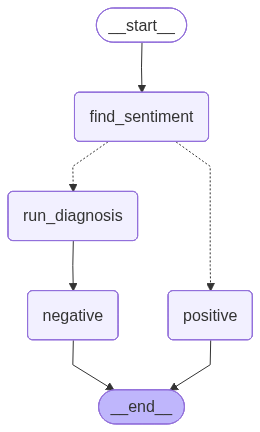

In [161]:
graph = StateGraph(SentimentState)

graph.add_node("positive", positive)
graph.add_node("negative", negative)
graph.add_node("find_sentiment", find_sentiment)
graph.add_node("run_diagnosis", run_diagnosis)

graph.add_edge(START, "find_sentiment")

graph.add_conditional_edges("find_sentiment", check_sentiment)

graph.add_edge('run_diagnosis', 'negative')
graph.add_edge('negative', END)

workflow = graph.compile()
workflow


In [162]:
initial_state: SentimentState = {
    'text': "Phone quality is very good. very good experience. I am satisfied."
    }

final_state = workflow.invoke(initial_state)

final_state

{'text': 'Phone quality is very good. very good experience. I am satisfied.',
 'sentiment': 'positive',
 'response': "Thank you so much for your wonderful feedback! We're thrilled to hear that you're satisfied with the phone quality and had a great experience. Your satisfaction is our top priority, and we're glad we could meet your expectations. If you have any questions or need assistance in the future, feel free to reach out. Enjoy your new phone!"}